In [6]:
# Install package
!pip install nltk openpyxl

# Import libraries
import pandas as pd
import nltk
import string

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nltk.download('stopwords')

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Get uploaded file name automatically
filename = list(uploaded.keys())[0]

# Read Excel file
df = pd.read_excel(filename)

# Select required columns
df = df[['text','label_num']]

# Rename columns
df.columns = ['message','label']

# Remove missing values
df.dropna(inplace=True)

# Preprocessing function
def clean_text(text):

    text = str(text).lower()

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    words = text.split()

    stop_words = set(stopwords.words('english'))

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Clean text
df['message'] = df['message'].apply(clean_text)

# Features and labels
X = df['message']
y = df['label']

# TF-IDF conversion
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

# Prediction
pred = model.predict(X_test)

# Accuracy
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

# Test custom mail
mail = [
    "Congratulations! You won $5000 claim now"
]

mail = tfidf.transform(mail)

result = model.predict(mail)

if result[0] == 1:
    print("Spam")
else:
    print("Ham")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving spam_ham_dataset.csv.xlsx to spam_ham_dataset.csv.xlsx
Accuracy: 0.8333333333333334
Ham


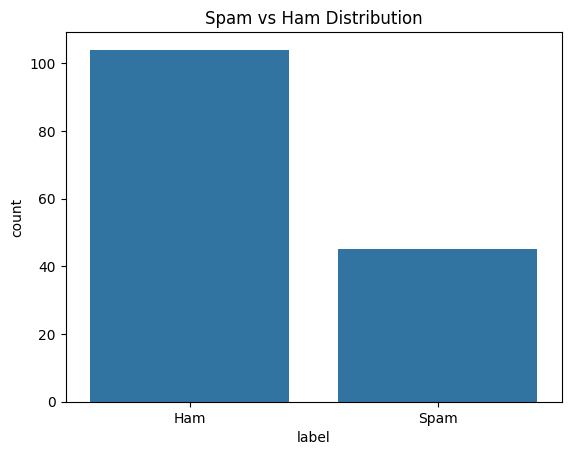

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)

plt.xticks(
    [0,1],
    ['Ham','Spam']
)

plt.title("Spam vs Ham Distribution")

plt.show()